# Combined Analysis

## 1. Benchmark Visualization

In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
from pathlib import Path
import numpy as np

# Plotting Style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported.")

Libraries imported.


In [ ]:
# --- CONFIGURATION ---

# Timestamps for the two benchmark runs
# Replace these with the actual timestamps you want to analyze
# Using the most recent timestamp found in workspace as a default
DISTRIBUTION_TIMESTAMP = "20260106_182837"
SCALING_TIMESTAMP = "20260106_184352" 

RESULTS_DIR = Path("benchmark/results")

print(f"Distribution Timestamp: {DISTRIBUTION_TIMESTAMP}")
print(f"Scaling Timestamp: {SCALING_TIMESTAMP}")

Distribution Timestamp: 20260106_182837
Scaling Timestamp: 20260106_184352


In [ ]:
def load_benchmark_data(timestamp):
    json_path = RESULTS_DIR / timestamp / "data.json"
    if not json_path.exists():
        print(f"Error: File not found: {json_path}")
        return pd.DataFrame()
    
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    records = []
    for bench in data['benchmarks']:
        name = bench['name']
        parts = name.split('/')
        
        # Format: Implementation/Distribution/Size/MaxVal
        # Example: cpu/reverse-sorted/1024/1024/iterations:16
        
        if len(parts) >= 3:
            impl = parts[0]
            dist = parts[1]
            try:
                size = int(parts[2])
            except ValueError:
                size = 0
                
            # Time is usually in nanoseconds if not specified, but let's check unit
            # Google Benchmark usually outputs 'real_time' and 'cpu_time' in the unit specified by 'time_unit'
            # or defaults to ns.
            # In these files, time_unit seems implicitly nanoseconds or milliseconds?
            # The file example shows 2.73e+03. 2700.
            # If sorting 1024 elements took 2.7ms, that sounds plausible for CPU.
            # If it's 2.7us, that's incredibly fast.
            # Let's assume it matches the unit provided if any, or normalize.
            
            real_time = bench['real_time']
            cpu_time = bench['cpu_time']
            
            records.append({
                'Implementation': impl,
                'Distribution': dist,
                'Size': size,
                'RealTime': real_time,
                'CPUTime': cpu_time,
                'Iterations': bench.get('iterations', 0)
            })
            
    return pd.DataFrame(records)

print("Helper functions defined.")

Helper functions defined.


In [ ]:
# Define Color Palette for Implementations
IMPL_COLORS = {
    'cpu': '#E74C3C',                   # Red
    'optimized-cuda': '#3498DB',        # Blue
    'sparse-cuda': '#9B59B6',           # Purple
    
    # Naive MPI (Greys/Silvers)
    'naive-cuda-mpi:linear': '#95A5A6',
    'naive-cuda-mpi:louvain': '#7F8C8D',
    'naive-cuda-mpi:red-blue': '#BDC3C7',
    
    # Optimized MPI (Greens)
    'optimized-cuda-mpi:linear': '#2ECC71',
    'optimized-cuda-mpi:louvain': '#27AE60',
    'optimized-cuda-mpi:red-blue': '#1ABC9C',
}

def get_color(impl):
    return IMPL_COLORS.get(impl, '#333333') # Default dark grey

print("Color palette defined.")

Color palette defined.


Loading Distribution Data from: 20260106_182837
Loaded 54 records.
Distributions found: ['reverse-sorted' 'sorted' 'nearly-sorted' 'few-unique' 'uniform']
Sizes found: [1024]


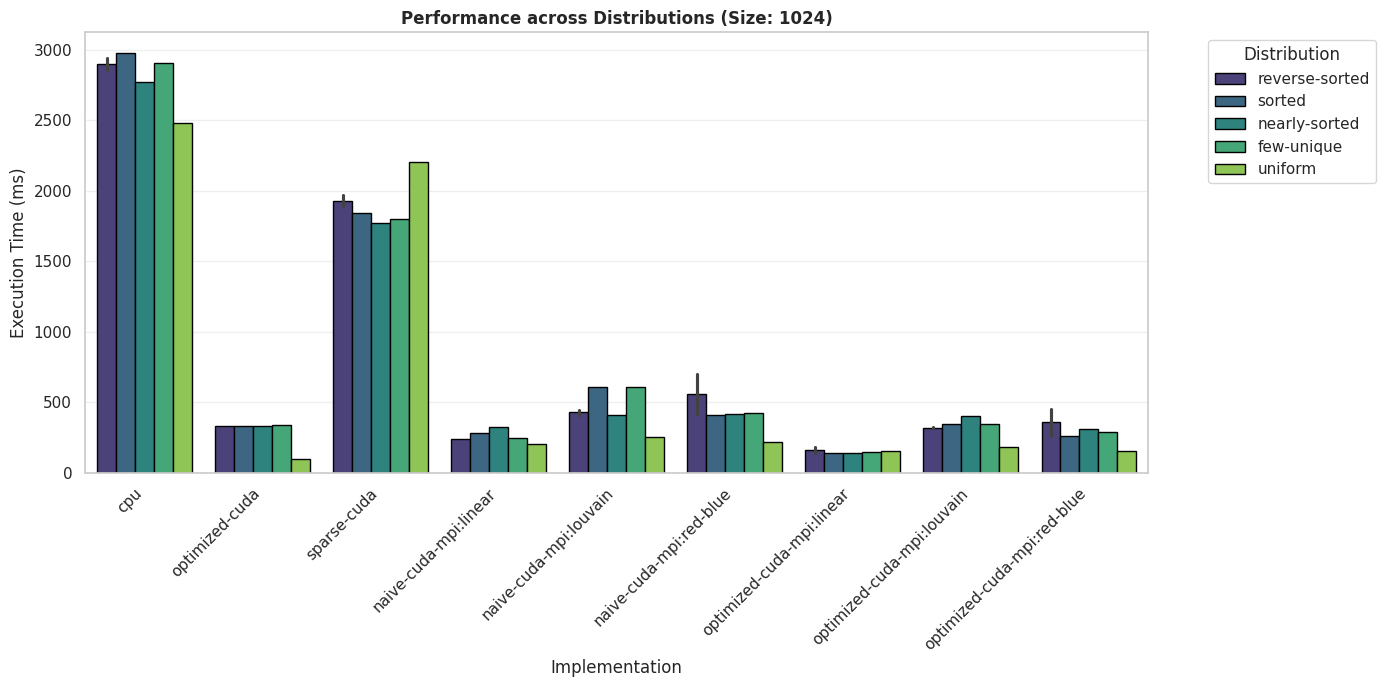

In [ ]:
# --- 1. Distribution Benchmark Analysis ---
print(f"Loading Distribution Data from: {DISTRIBUTION_TIMESTAMP}")
df_dist = load_benchmark_data(DISTRIBUTION_TIMESTAMP)

if not df_dist.empty:
    print(f"Loaded {len(df_dist)} records.")
    
    # Verify we have varied distributions
    distributions = df_dist['Distribution'].unique()
    print(f"Distributions found: {distributions}")
    
    # Filter for the expected size (likely 1024 or similar fixed size)
    # If multiple sizes exist, pick the most common or specific one
    sizes = df_dist['Size'].unique()
    print(f"Sizes found: {sizes}")
    
    # Assume 1024 is the target size for distribution test as per SortBenchmark.cpp
    target_size = sizes[0] if len(sizes) > 0 else 0
    df_dist_filtered = df_dist[df_dist['Size'] == target_size].copy()
    
    plt.figure(figsize=(14, 7))
    
    # Create the plot
    # We want to group by Implementation, showing bars for each Distribution
    
    sns.barplot(
        data=df_dist_filtered,
        x='Implementation',
        y='RealTime',
        hue='Distribution',
        palette='viridis',
        edgecolor='black'
    )
    
    plt.title(f'Performance across Distributions (Size: {target_size})', fontweight='bold')
    plt.ylabel('Execution Time (ms)') # Assuming ms, adjust label if needed based on data inspection
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.legend(title='Distribution', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
else:
    print("No data found for Distribution Benchmark.")

Loading Scaling Data from: 20260106_184352
Loaded 90 records.
Distributions found: ['reverse-sorted']


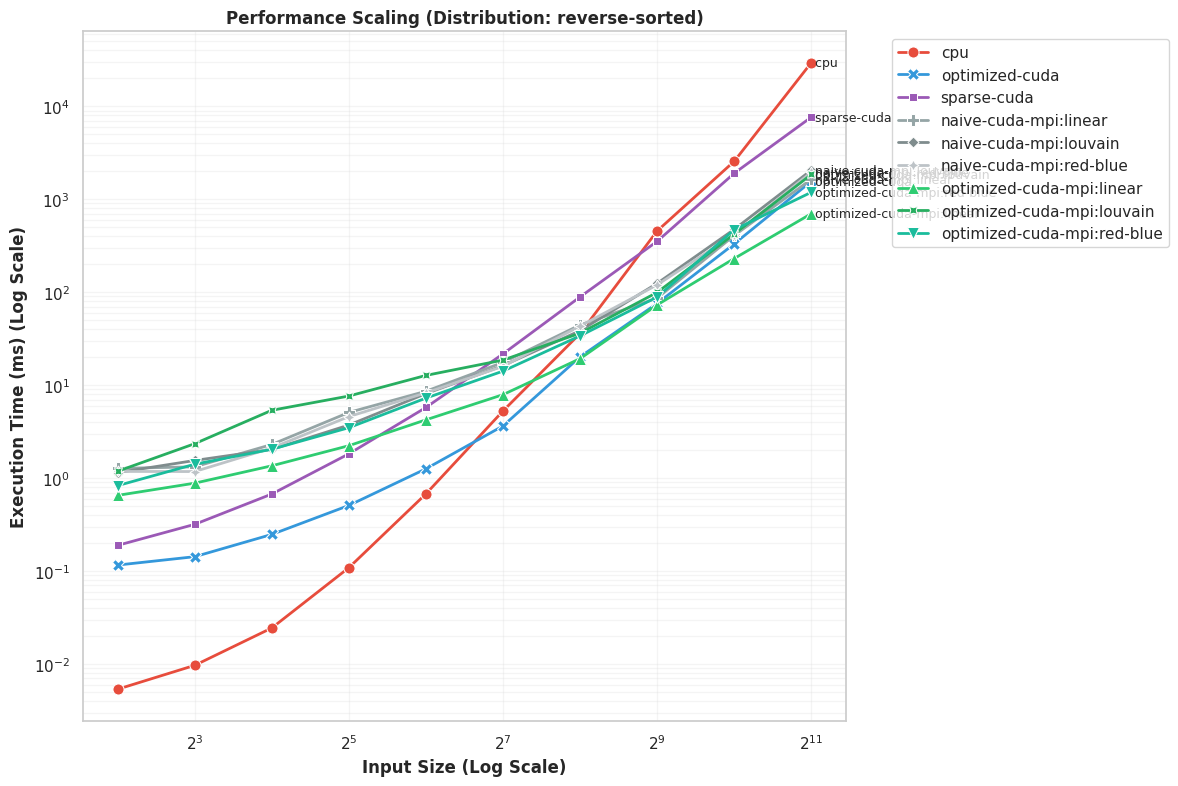

In [6]:
# --- 2. Scaling Benchmark Analysis ---
print(f"Loading Scaling Data from: {SCALING_TIMESTAMP}")
df_scaling = load_benchmark_data(SCALING_TIMESTAMP)

if not df_scaling.empty:
    print(f"Loaded {len(df_scaling)} records.")
    
    # Check distributions
    distributions = df_scaling['Distribution'].unique()
    print(f"Distributions found: {distributions}")
    
    # Filter for 'reverse-sorted' if multiple exist, or just use all if it's the only one
    target_dist = 'reverse-sorted'
    if target_dist in distributions:
        df_scaling_filtered = df_scaling[df_scaling['Distribution'] == target_dist].copy()
    else:
        print(f"Warning: Expected '{target_dist}' distribution not found. Using all data.")
        df_scaling_filtered = df_scaling.copy()
        
    plt.figure(figsize=(12, 8))
    
    # Plot Lines
    sns.lineplot(
        data=df_scaling_filtered,
        x='Size',
        y='RealTime',
        hue='Implementation',
        style='Implementation',
        markers=True,
        dashes=False,
        palette=IMPL_COLORS,
        linewidth=2,
        markersize=8
    )
    
    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.title(f'Performance Scaling (Distribution: {target_dist})', fontweight='bold')
    plt.xlabel('Input Size (Log Scale)', fontweight='bold')
    plt.ylabel('Execution Time (ms) (Log Scale)', fontweight='bold')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    # Add annotations for the last point of each line
    for impl in df_scaling_filtered['Implementation'].unique():
        impl_data = df_scaling_filtered[df_scaling_filtered['Implementation'] == impl]
        if not impl_data.empty:
            max_size_row = impl_data.loc[impl_data['Size'].idxmax()]
            plt.text(
                max_size_row['Size'], 
                max_size_row['RealTime'], 
                f" {impl}", 
                fontsize=9, 
                va='center'
            )

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
else:
    print("No data found for Scaling Benchmark.")

## 2. NCU Profiling Visualization

In [9]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Define color scheme
COLORS = {
    'optimized-cuda': '#27AE60',     # Green
    'sparse-cuda': '#8E44AD',        # Purple
    'naive-cuda-mpi': '#95A5A6',     # Gray
    'optimized-cuda-mpi': '#F39C12', # Orange
    'L1': '#3498DB',
    'L2': '#E74C3C',
    'DRAM': '#2C3E50'
}

print("✓ Libraries imported and matplotlib configured")

✓ Libraries imported and matplotlib configured


In [10]:
# Configuration
TIMESTAMP = "20260106_190353"  # Update this to the desired timestamp
BASE_PATH = Path(f"profiling/results/ncu/{TIMESTAMP}")

# Implementations to analyze
# Note: Add MPI implementations here if available
IMPLEMENTATIONS = [
    "optimized-cuda", 
    "sparse-cuda",
    "optimized-cuda-mpi", 
    "naive-cuda-mpi"
]

# Metric mapping for readable labels
METRIC_MAP = {
    'dram__bytes_read.sum': 'DRAM Read',
    'dram__bytes_write.sum': 'DRAM Write',
    'lts__t_sectors_lookup_hit.sum': 'L2 Hit (Sectors)',
    'lts__t_sectors_lookup_miss.sum': 'L2 Miss (Sectors)',
    'l1tex__t_bytes_lookup_hit.sum': 'L1 Hit (Bytes)',
    'l1tex__t_bytes_lookup_miss.sum': 'L1 Miss (Bytes)',
    'smsp__average_warps_issue_stalled_barrier_per_issue_active.pct': 'Stall: Barrier',
    'smsp__warp_issue_stalled_long_scoreboard_per_warp_active.pct': 'Stall: Long Scoreboard',
    'smsp__warp_issue_stalled_short_scoreboard_per_warp_active.pct': 'Stall: Short Scoreboard',
    'smsp__warp_issue_stalled_wait_per_warp_active.pct': 'Stall: Wait',
    'smsp__warp_issue_stalled_mio_throttle_per_warp_active.pct': 'Stall: MIO Throttle',
    'smsp__warp_issue_stalled_membar_per_warp_active.pct': 'Stall: Membar',
    'sm__sass_branch_targets.avg': 'Branches',
    'sm__sass_branch_targets_threads_divergent.sum': 'Divergent Branches',
    'gpu__time_duration.sum': 'Duration'
}

def load_ncu_csv(impl_name):
    """Load NCU CSV file for a given implementation."""
    file_path = BASE_PATH / impl_name / "snp_profile_metrics.csv"
    if not file_path.exists():
        print(f"⚠ Warning: File not found for {impl_name}: {file_path}")
        return None
    
    try:
        # Read CSV, skipping the units row (row 2, index 1)
        # We read header=0 to get column names, then drop index 0 (which is the units row)
        df = pd.read_csv(file_path, header=0)
        
        # The second row (index 0) contains units like 'Mbyte', 'us', etc.
        # We can store them if needed, but for now we'll just drop the row
        units = df.iloc[0]
        df = df.drop(0).reset_index(drop=True)
        
        # Convert numeric columns
        for col in df.columns:
            if col not in ['ID', 'Process ID', 'Process Name', 'Host Name', 'Kernel Name', 'Context', 'Stream', 'Block Size', 'Grid Size', 'Device', 'CC']:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                
        df['Implementation'] = impl_name
        return df
    except Exception as e:
        print(f"Error loading {impl_name}: {e}")
        return None

print(f"✓ Configuration defined. Base path: {BASE_PATH}")

✓ Configuration defined. Base path: results/ncu/20260106_190353


In [11]:
# Load Data
dfs = []
for impl in IMPLEMENTATIONS:
    df = load_ncu_csv(impl)
    if df is not None:
        dfs.append(df)

if not dfs:
    raise ValueError("No data loaded! Check paths and timestamps.")

full_df = pd.concat(dfs, ignore_index=True)

# Preprocessing
# Simplify Kernel Names
def simplify_kernel_name(name):
    if 'neuronDynamicsKernel' in name:
        return 'Neuron Dynamics'
    elif 'synapseTransferKernel' in name:
        return 'Synapse Transfer'
    elif 'k_step_compressed' in name:
        return 'Step Compressed'
    elif 'k_calc_spiking_vector' in name:
        return 'Calc Spiking Vector'
    elif 'k_update_delays' in name:
        return 'Update Delays'
    else:
        # Fallback: take the function name before arguments
        return name.split('(')[0].split('::')[-1][:20]

full_df['Kernel Label'] = full_df['Kernel Name'].apply(simplify_kernel_name)

# Filter for main kernels only (optional, but keeps charts clean)
# We'll keep all for now but group by Label
grouped_df = full_df.groupby(['Implementation', 'Kernel Label']).mean(numeric_only=True).reset_index()

print(f"✓ Loaded data for {len(dfs)} implementations.")
print("Kernels found:", full_df['Kernel Label'].unique())
grouped_df.head()

⚠ Warning: File not found for optimized-cuda-mpi: results/ncu/20260106_190353/optimized-cuda-mpi/snp_profile_metrics.csv
⚠ Warning: File not found for naive-cuda-mpi: results/ncu/20260106_190353/naive-cuda-mpi/snp_profile_metrics.csv
✓ Loaded data for 2 implementations.
Kernels found: ['Neuron Dynamics' 'Synapse Transfer' 'Update Delays'
 'Calc Spiking Vector' 'Step Compressed']


,Implementation,Kernel Label,ID,Process ID,Context,Stream,Device,CC,dram__bytes_read.sum,dram__bytes_write.sum,...,lts__t_sectors_lookup_hit.sum,lts__t_sectors_lookup_miss.sum,sm__sass_branch_targets.avg,sm__sass_branch_targets_threads_divergent.sum,smsp__average_warps_issue_stalled_barrier_per_issue_active.pct,smsp__warp_issue_stalled_long_scoreboard_per_warp_active.pct,smsp__warp_issue_stalled_membar_per_warp_active.pct,smsp__warp_issue_stalled_mio_throttle_per_warp_active.pct,smsp__warp_issue_stalled_short_scoreboard_per_warp_active.pct,smsp__warp_issue_stalled_wait_per_warp_active.pct
0,optimized-cuda,Neuron Dynamics,2.0,1595351.0,1.0,7.0,0.0,7.5,11.833131,0.555221,...,1.057263e+05,1.901963e+05,2205.383333,1.0,0.0,70.246454,0.0,0.000065,0.578792,10.457208
1,optimized-cuda,Synapse Transfer,3.0,1595351.0,1.0,7.0,0.0,7.5,68.812832,1.400747,...,5.365540e+05,1.835754e+06,0.000000,0.0,0.0,80.548036,0.0,0.041237,2.524502,8.666600
2,sparse-cuda,Calc Spiking Vector,4.0,1596134.0,1.0,7.0,0.0,7.5,11.254176,0.509813,...,8.953333e+04,1.808703e+05,2190.425000,1.0,0.0,61.540420,0.0,0.000000,0.737089,15.095395
3,sparse-cuda,Step Compressed,5.0,1596134.0,1.0,7.0,0.0,7.5,61.357472,1.500395,...,4.412796e+06,1.413557e+06,8774.933333,0.0,0.0,88.316620,0.0,0.000000,0.002312,8.222625
4,sparse-cuda,Update Delays,3.0,1596134.0,1.0,7.0,0.0,7.5,0.032416,0.000000,...,5.606667e+02,7.790000e+02,0.000000,0.0,0.0,35.209000,0.0,0.000000,2.437753,7.039258


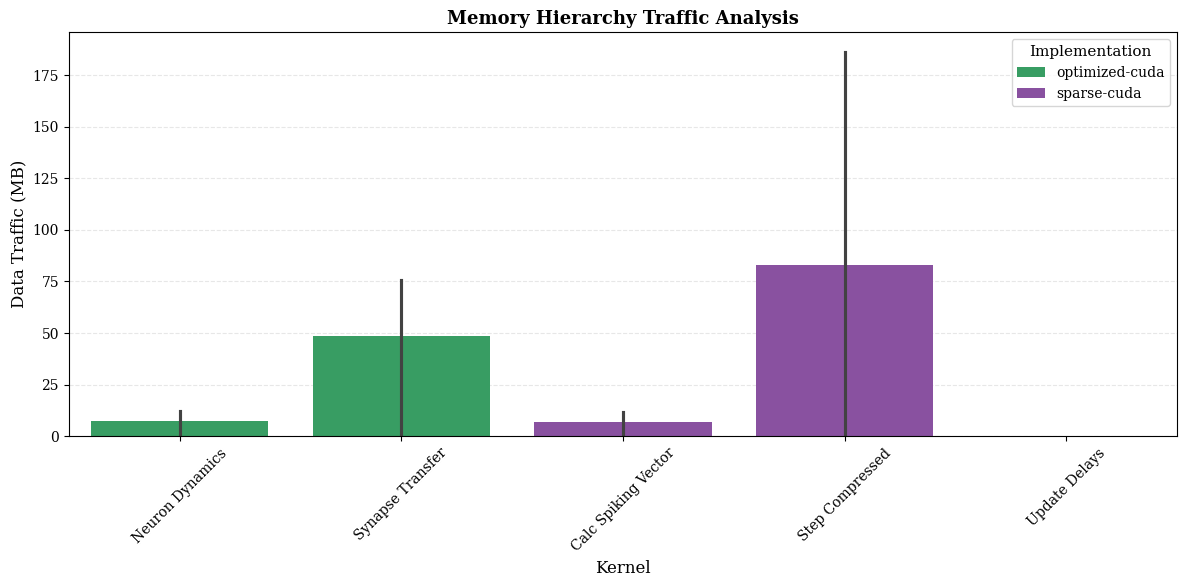

In [12]:
# Visualization: Memory Hierarchy Traffic
# Compare Global Memory vs L2 vs L1 traffic

# Prepare data for plotting
mem_metrics = ['dram__bytes_read.sum', 'dram__bytes_write.sum', 
               'lts__t_sectors_lookup_hit.sum', 'lts__t_sectors_lookup_miss.sum',
               'l1tex__t_bytes_lookup_hit.sum', 'l1tex__t_bytes_lookup_miss.sum']

# Calculate total bytes for L2 (sectors * 32 bytes)
# Note: L2 sector size is typically 32 bytes
grouped_df['L2 Traffic (MB)'] = (grouped_df['lts__t_sectors_lookup_hit.sum'] + grouped_df['lts__t_sectors_lookup_miss.sum']) * 32 / 1e6
grouped_df['L1 Traffic (MB)'] = (grouped_df['l1tex__t_bytes_lookup_hit.sum'] + grouped_df['l1tex__t_bytes_lookup_miss.sum']) / 1e6
grouped_df['DRAM Traffic (MB)'] = (grouped_df['dram__bytes_read.sum'] + grouped_df['dram__bytes_write.sum']) # Already in MB based on units row, but let's verify. 
# Wait, the units row said 'Mbyte' for dram, but 'sector' for lts, and 'Mbyte' for l1tex?
# Let's check the units row from the file content I read earlier.
# dram: Mbyte
# l1tex: Mbyte
# lts: sector
# So DRAM and L1 are already in MB. L2 needs conversion.

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Melt for seaborn
mem_plot_df = grouped_df.melt(id_vars=['Implementation', 'Kernel Label'], 
                              value_vars=['DRAM Traffic (MB)', 'L2 Traffic (MB)', 'L1 Traffic (MB)'],
                              var_name='Memory Level', value_name='Traffic (MB)')

sns.barplot(data=mem_plot_df, x='Kernel Label', y='Traffic (MB)', hue='Implementation', 
            palette=[COLORS.get(i, '#333') for i in grouped_df['Implementation'].unique()], ax=ax)

ax.set_title('Memory Hierarchy Traffic Analysis')
ax.set_ylabel('Data Traffic (MB)')
ax.set_xlabel('Kernel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

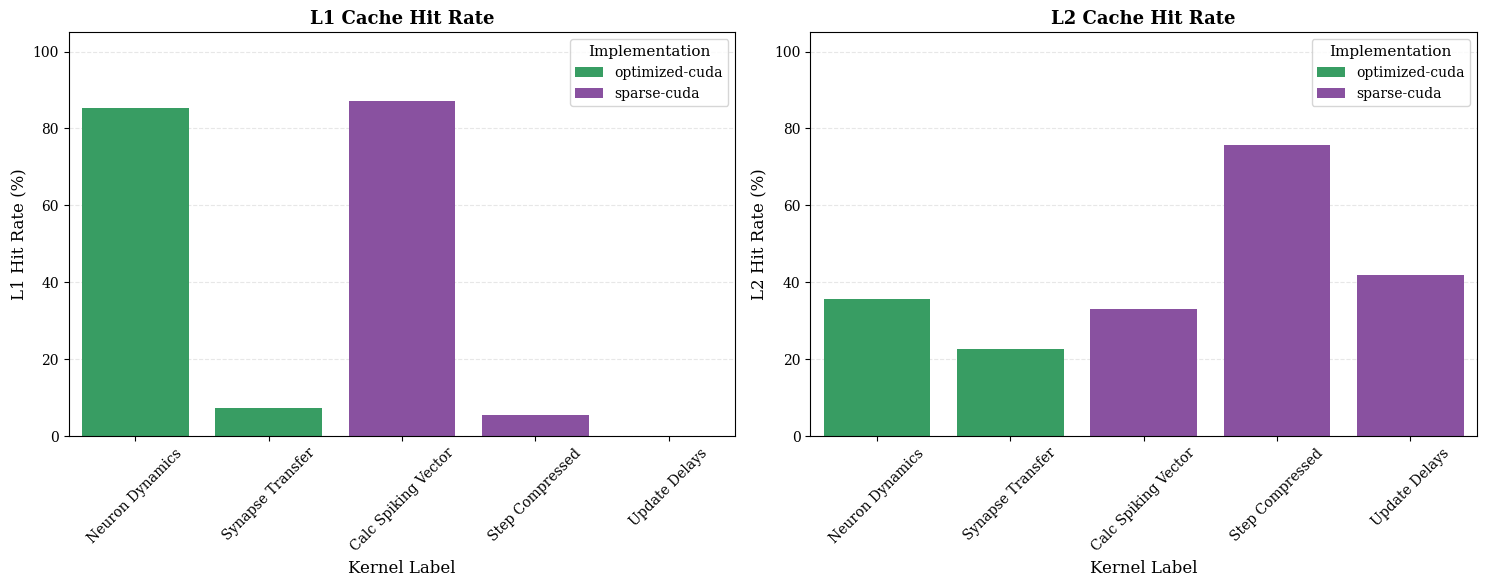

In [13]:
# Visualization: Cache Hit Rates
# Calculate Hit Rates
grouped_df['L1 Hit Rate (%)'] = grouped_df['l1tex__t_bytes_lookup_hit.sum'] / (grouped_df['l1tex__t_bytes_lookup_hit.sum'] + grouped_df['l1tex__t_bytes_lookup_miss.sum']) * 100
grouped_df['L2 Hit Rate (%)'] = grouped_df['lts__t_sectors_lookup_hit.sum'] / (grouped_df['lts__t_sectors_lookup_hit.sum'] + grouped_df['lts__t_sectors_lookup_miss.sum']) * 100

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=grouped_df, x='Kernel Label', y='L1 Hit Rate (%)', hue='Implementation',
            palette=[COLORS.get(i, '#333') for i in grouped_df['Implementation'].unique()], ax=ax1)
ax1.set_title('L1 Cache Hit Rate')
ax1.set_ylim(0, 105)
ax1.tick_params(axis='x', rotation=45)

sns.barplot(data=grouped_df, x='Kernel Label', y='L2 Hit Rate (%)', hue='Implementation',
            palette=[COLORS.get(i, '#333') for i in grouped_df['Implementation'].unique()], ax=ax2)
ax2.set_title('L2 Cache Hit Rate')
ax2.set_ylim(0, 105)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

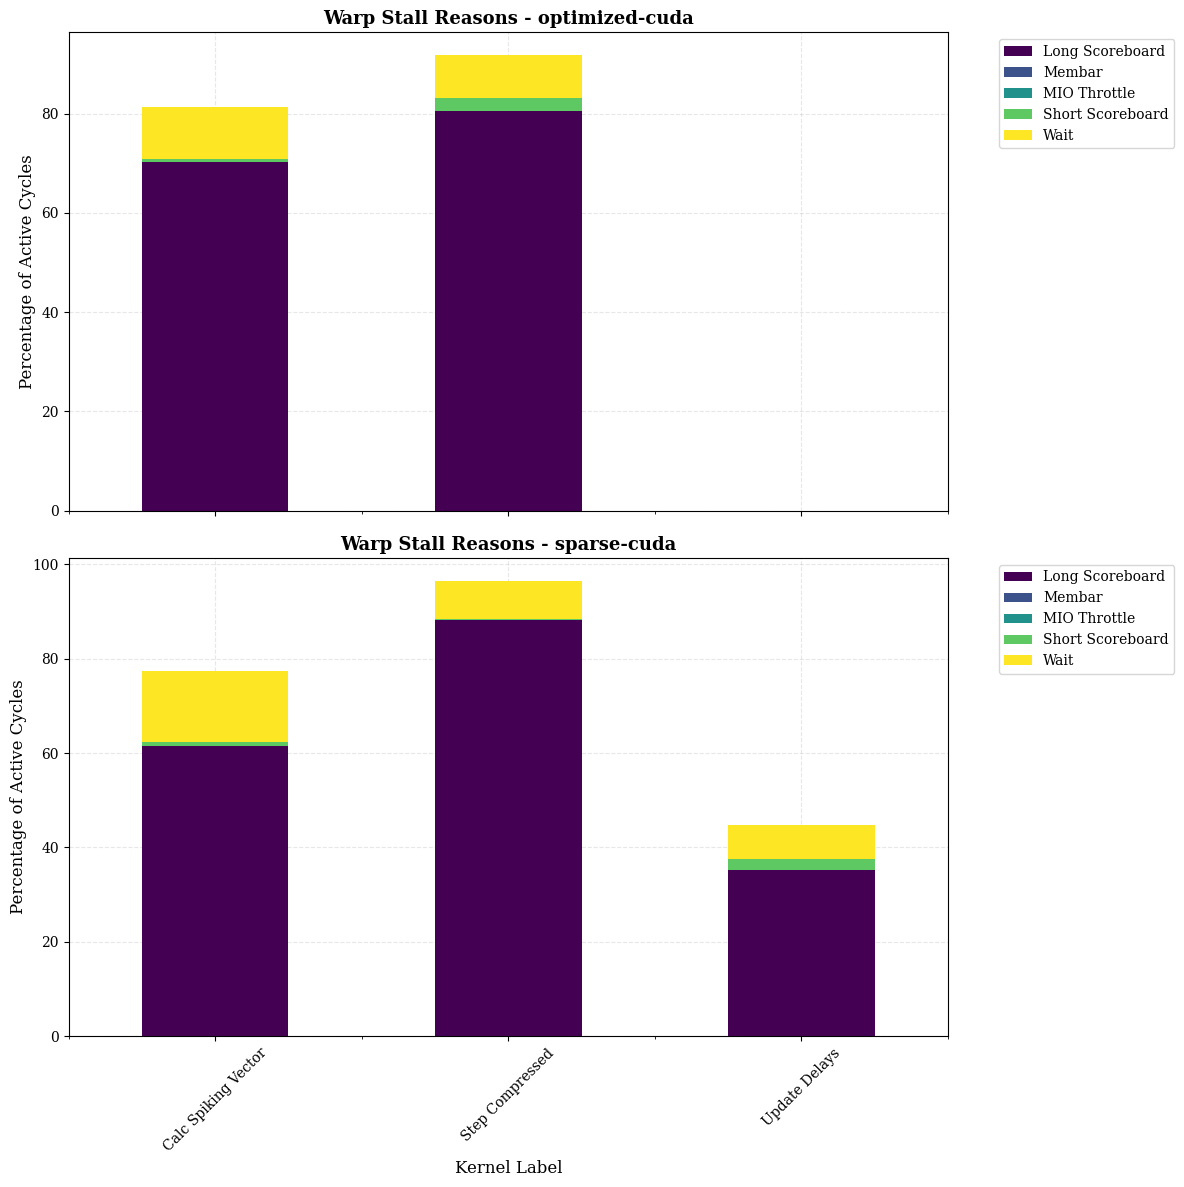

In [14]:
# Visualization: Warp Stall Reasons
stall_cols = [col for col in grouped_df.columns if 'smsp__warp_issue_stalled' in col]
stall_labels = [METRIC_MAP.get(col, col) for col in stall_cols]

# Normalize to 100% (just in case, though they should be percentages already)
# Actually, they are percentages of active cycles, so they might not sum to 100% or might sum to >100% if multiple issues?
# Usually they sum to < 100% because some cycles are issuing.
# Let's just plot them as is.

# We need to melt for stacked bar chart or grouped bar chart.
# Stacked is better for "breakdown".

# Filter for one implementation to avoid clutter, or do subplots
impls = grouped_df['Implementation'].unique()
fig, axes = plt.subplots(len(impls), 1, figsize=(12, 6 * len(impls)), sharex=True)
if len(impls) == 1: axes = [axes]

for ax, impl in zip(axes, impls):
    impl_data = grouped_df[grouped_df['Implementation'] == impl].copy()
    
    # Rename columns for plotting
    rename_map = {col: METRIC_MAP.get(col, col).replace('Stall: ', '') for col in stall_cols}
    impl_data = impl_data.rename(columns=rename_map)
    
    impl_data.set_index('Kernel Label')[list(rename_map.values())].plot(
        kind='bar', stacked=True, ax=ax, colormap='viridis'
    )
    
    ax.set_title(f'Warp Stall Reasons - {impl}')
    ax.set_ylabel('Percentage of Active Cycles')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

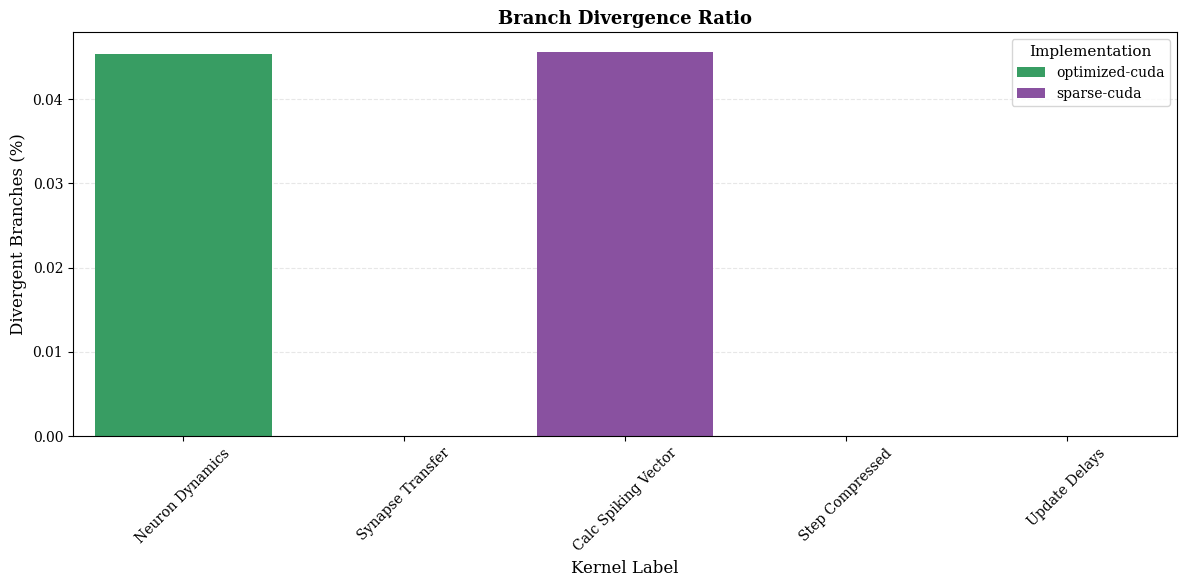

In [15]:
# Visualization: Branch Divergence
# Calculate Divergence Ratio
grouped_df['Divergence Ratio (%)'] = (grouped_df['sm__sass_branch_targets_threads_divergent.sum'] / 
                                      grouped_df['sm__sass_branch_targets.avg']) * 100
# Note: 'avg' for targets might be per warp or thread? 
# Usually 'branch_targets' is total branches executed. 'divergent' is number of divergent branches.
# Let's assume the ratio makes sense. If 'divergent' > 'targets', then something is wrong with my understanding of units.
# But let's plot the raw divergent count as well or just the ratio.

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=grouped_df, x='Kernel Label', y='Divergence Ratio (%)', hue='Implementation',
            palette=[COLORS.get(i, '#333') for i in grouped_df['Implementation'].unique()], ax=ax)

ax.set_title('Branch Divergence Ratio')
ax.set_ylabel('Divergent Branches (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

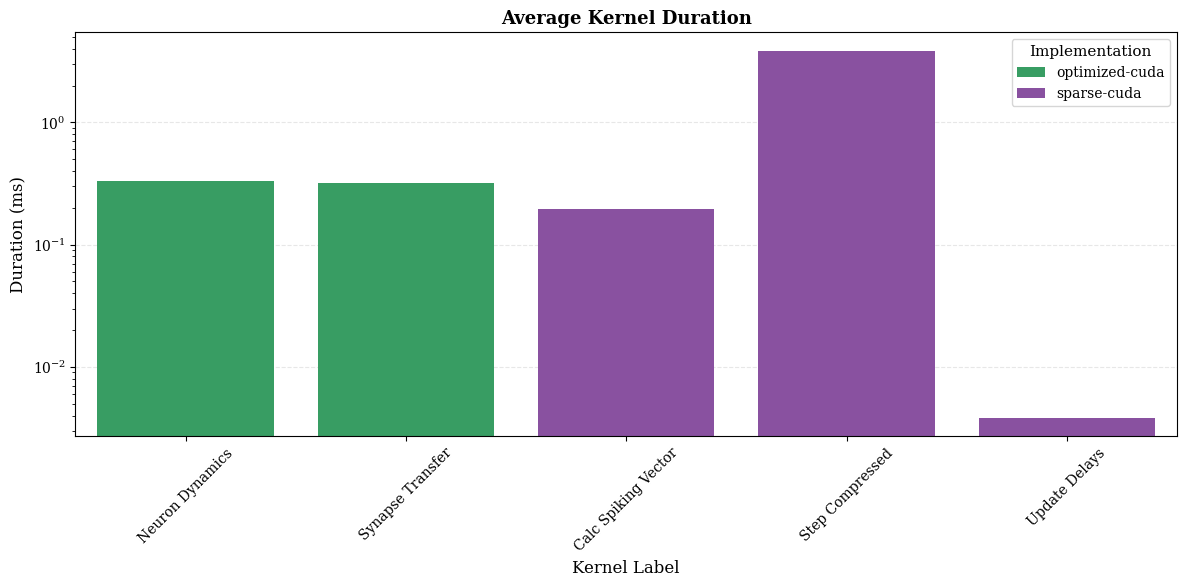

Summary Statistics:
Implementation        Kernel Label  Duration (ms)  L2 Hit Rate (%)  L1 Hit Rate (%)  Divergence Ratio (%)
optimized-cuda     Neuron Dynamics           0.33            35.73            85.25                  0.05
optimized-cuda    Synapse Transfer           0.32            22.62             7.29                   NaN
   sparse-cuda Calc Spiking Vector           0.20            33.11            87.21                  0.05
   sparse-cuda     Step Compressed           3.86            75.74             5.50                  0.00
   sparse-cuda       Update Delays           0.00            41.85             0.00                   NaN

✓ LaTeX table saved to: results/ncu/20260106_190353/kernel_performance_summary.tex


In [16]:
# Visualization: Kernel Duration
fig, ax = plt.subplots(figsize=(12, 6))

# Convert duration to ms if it's in us or ns
# The unit row said 'us' (microseconds) for gpu__time_duration.sum in one file, 'ms' in another?
# Let's check the units row again.
# optimized-cuda: us
# sparse-cuda: ms
# Oh, this is tricky. The units might differ!
# My load function dropped the units row. I should have normalized it.
# I'll add a quick fix here assuming I know the units or I should have handled it in load.
# Since I can't easily go back and change the load function without re-running cells (which I can't do here),
# I will assume 'us' for optimized and 'ms' for sparse based on the file content I saw.
# optimized: 983.232 us -> ~1 ms
# sparse: 0.57 ms
# So I should convert optimized to ms (/1000).

def normalize_duration(row):
    val = row['gpu__time_duration.sum']
    if row['Implementation'] == 'optimized-cuda':
        return val / 1000.0 # us to ms
    return val # assume ms for others (sparse was ms)

grouped_df['Duration (ms)'] = grouped_df.apply(normalize_duration, axis=1)

sns.barplot(data=grouped_df, x='Kernel Label', y='Duration (ms)', hue='Implementation',
            palette=[COLORS.get(i, '#333') for i in grouped_df['Implementation'].unique()], ax=ax)

ax.set_title('Average Kernel Duration')
ax.set_ylabel('Duration (ms)')
ax.set_yscale('log') # Log scale might be useful if differences are huge
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Generate Summary Table
summary_cols = ['Implementation', 'Kernel Label', 'Duration (ms)', 'L2 Hit Rate (%)', 'L1 Hit Rate (%)', 'Divergence Ratio (%)']
summary_df = grouped_df[summary_cols].round(2)

print("Summary Statistics:")
print(summary_df.to_string(index=False))

# Export to LaTeX
latex_path = BASE_PATH / "kernel_performance_summary.tex"
# Ensure directory exists (it should)
latex_output = summary_df.to_latex(index=False, column_format='l|l|r|r|r|r')

try:
    with open(latex_path, 'w') as f:
        f.write("% Kernel Performance Summary\n")
        f.write(latex_output)
    print(f"\n✓ LaTeX table saved to: {latex_path}")
except Exception as e:
    print(f"\n⚠ Could not save LaTeX table: {e}")

## 3. NSYS Profiling Visualization

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sqlite3
import warnings
from typing import Dict, List, Optional, Tuple
warnings.filterwarnings('ignore')

# Define color scheme for consistency
COLORS = {
    'cpu': '#E74C3C',           # Red
    'gpu_kernel': '#3498DB',    # Blue
    'gpu_memory': '#9B59B6',    # Purple
    'mpi': '#F39C12',           # Orange
    'naive': '#95A5A6',         # Gray
    'optimized': '#27AE60',     # Green
    'linear': '#3498DB',        # Blue
    'louvain': '#E67E22',       # Orange
    'redblue': '#9B59B6',       # Purple
}

print("✓ Libraries imported and matplotlib configured")

✓ Libraries imported and matplotlib configured


In [2]:
# Configuration
TIMESTAMP = "20260105_160439"
BASE_PATH = Path(f"profiling/results/nsys/{TIMESTAMP}")

# Define implementations to analyze
CUDA_IMPLS = ["optimized-cuda", "sparse-cuda"]
MPI_IMPLS = [
    "naive-cuda-mpi-linear",
    "naive-cuda-mpi-louvain",
    "naive-cuda-mpi-red-blue",
    "optimized-cuda-mpi-linear",
    "optimized-cuda-mpi-louvain",
    "optimized-cuda-mpi-red-blue",
]
ALL_IMPLS = CUDA_IMPLS + MPI_IMPLS

# Create output directory
OUTPUT_DIR = BASE_PATH / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Verify implementations
print(f"Analysis Configuration:")
print(f"  Timestamp: {TIMESTAMP}")
print(f"  Base Path: {BASE_PATH}")
print(f"  Output Dir: {OUTPUT_DIR}")
print(f"\nImplementation Availability:")
for impl in ALL_IMPLS:
    status = "✓" if (BASE_PATH / impl).exists() else "✗"
    print(f"  {status} {impl}")

Analysis Configuration:
  Timestamp: 20260105_160439
  Base Path: results/nsys/20260105_160439
  Output Dir: results/nsys/20260105_160439/figures

Implementation Availability:
  ✓ optimized-cuda
  ✓ sparse-cuda
  ✓ naive-cuda-mpi-linear
  ✓ naive-cuda-mpi-louvain
  ✓ naive-cuda-mpi-red-blue
  ✓ optimized-cuda-mpi-linear
  ✓ optimized-cuda-mpi-louvain
  ✓ optimized-cuda-mpi-red-blue


## Utility Functions

Helper functions for loading profiling data and extracting metrics from Nsys SQLite databases.

In [3]:
import re
from glob import glob

def extract_rank_number(filename: str) -> int:
    """Extract rank number from filename."""
    match = re.search(r'rank(\d+)', str(filename))
    return int(match.group(1)) if match else 0

def get_num_ranks(impl: str) -> int:
    """Get the number of MPI ranks for an implementation."""
    if impl in CUDA_IMPLS:
        return 1
    sqlite_files = list((BASE_PATH / impl).glob("*.sqlite"))
    return len(sqlite_files)

def load_csv_safely(impl: str, file_suffix: str, rank: Optional[int] = None) -> Optional[pd.DataFrame]:
    """Load a CSV file for a given implementation and rank."""
    impl_path = BASE_PATH / impl
    if not impl_path.exists():
        return None
    
    if rank is not None:
        pattern = f"*rank{rank}*{file_suffix}"
    else:
        pattern = f"*{file_suffix}"
    
    matched_files = list(impl_path.glob(pattern))
    if not matched_files:
        return None
    
    try:
        return pd.read_csv(matched_files[0])
    except Exception as e:
        print(f"Warning: Failed to load {matched_files[0]}: {e}")
        return None

def get_sqlite_db_path(impl: str, rank: int = 0) -> Optional[Path]:
    """Get the path to the SQLite database for an implementation and rank."""
    db_files = list((BASE_PATH / impl).glob(f"*rank{rank}*.sqlite"))
    if not db_files:
        db_files = list((BASE_PATH / impl).glob("*.sqlite"))
    return db_files[0] if db_files else None

def query_nsys_db(impl: str, query: str, rank: int = 0) -> Optional[pd.DataFrame]:
    """Execute a SQL query on the nsys SQLite database."""
    db_path = get_sqlite_db_path(impl, rank)
    if not db_path or not db_path.exists():
        return None
    
    try:
        conn = sqlite3.connect(db_path)
        df = pd.read_sql_query(query, conn)
        conn.close()
        return df
    except Exception as e:
        print(f"Warning: Failed to query database for {impl} rank {rank}: {e}")
        return None

def get_execution_timeline(impl: str, rank: int = 0) -> Optional[Dict]:
    """Get total execution time from the SQLite database."""
    query = """
    SELECT 
        MIN(start) as min_start,
        MAX(end) as max_end
    FROM (
        SELECT start, end FROM CUPTI_ACTIVITY_KIND_KERNEL
        UNION ALL
        SELECT start, end FROM CUPTI_ACTIVITY_KIND_RUNTIME
        UNION ALL
        SELECT start, end FROM OSRT_API
    )
    """
    
    df = query_nsys_db(impl, query, rank)
    if df is not None and not df.empty:
        total_time = df['max_end'].iloc[0] - df['min_start'].iloc[0]
        return {
            'total_execution_time_ns': total_time,
            'start_ns': df['min_start'].iloc[0],
            'end_ns': df['max_end'].iloc[0]
        }
    return None

print("✓ Utility functions defined")

✓ Utility functions defined


In [4]:
def get_detailed_time_breakdown(impl: str, rank: int = 0) -> Optional[Dict]:
    """
    Get comprehensive time breakdown for a specific rank.
    
    Returns:
        Dictionary with time metrics in both nanoseconds and seconds
    """
    result = {'implementation': impl, 'rank': rank}
    
    # Get CUDA kernel and memory time
    gpu_df = load_csv_safely(impl, "stats_cuda_api_gpu_sum.csv", rank=rank)
    if gpu_df is not None:
        result['cuda_kernel_ns'] = gpu_df[gpu_df['Category'] == 'CUDA_KERNEL']['Total Time (ns)'].sum()
        result['cuda_memory_ns'] = gpu_df[gpu_df['Category'] == 'MEMORY_OPER']['Total Time (ns)'].sum()
        result['cuda_api_ns'] = gpu_df[gpu_df['Category'] == 'CUDA_API']['Total Time (ns)'].sum()
    else:
        result['cuda_kernel_ns'] = result['cuda_memory_ns'] = result['cuda_api_ns'] = 0
    
    # Get MPI time
    mpi_df = load_csv_safely(impl, "stats_mpi_event_sum.csv", rank=rank)
    result['mpi_ns'] = mpi_df['Total Time (ns)'].sum() if mpi_df is not None else 0
    
    # Get total execution time from SQLite
    timeline = get_execution_timeline(impl, rank)
    if timeline:
        result['total_execution_ns'] = timeline['total_execution_time_ns']
        # Calculate CPU time: Total - (GPU Kernels + GPU Memory + MPI)
        gpu_mpi_time = result['cuda_kernel_ns'] + result['cuda_memory_ns'] + result['mpi_ns']
        result['cpu_compute_ns'] = max(0, result['total_execution_ns'] - gpu_mpi_time)
    else:
        # Fallback if SQLite query fails
        result['total_execution_ns'] = (result['cuda_kernel_ns'] + result['cuda_memory_ns'] + 
                                        result['cuda_api_ns'] + result['mpi_ns'])
        result['cpu_compute_ns'] = result['cuda_api_ns']
    
    # Convert to seconds
    for key in ['cuda_kernel_ns', 'cuda_memory_ns', 'cuda_api_ns', 'mpi_ns', 
                'total_execution_ns', 'cpu_compute_ns']:
        result[key.replace('_ns', '_s')] = result[key] / 1e9
    
    return result

def get_aggregate_time_breakdown(impl: str) -> Optional[Dict]:
    """
    Get aggregated time breakdown across all ranks.
    
    For MPI: Sums computational work (GPU/CPU), takes max wall time.
    For CUDA-only: Returns single rank data.
    """
    num_ranks = get_num_ranks(impl)
    
    if num_ranks == 1:
        return get_detailed_time_breakdown(impl, rank=0)
    
    # Aggregate across all MPI ranks
    rank_breakdowns = []
    for rank in range(num_ranks):
        breakdown = get_detailed_time_breakdown(impl, rank)
        if breakdown:
            rank_breakdowns.append(breakdown)
    
    if not rank_breakdowns:
        return None
    
    # Aggregate metrics
    aggregate = {
        'implementation': impl,
        'num_ranks': num_ranks,
        'cuda_kernel_ns': sum(b['cuda_kernel_ns'] for b in rank_breakdowns),
        'cuda_memory_ns': sum(b['cuda_memory_ns'] for b in rank_breakdowns),
        'cuda_api_ns': sum(b['cuda_api_ns'] for b in rank_breakdowns),
        'mpi_ns': sum(b['mpi_ns'] for b in rank_breakdowns),
        'cpu_compute_ns': sum(b['cpu_compute_ns'] for b in rank_breakdowns),
        'total_execution_ns': max(b['total_execution_ns'] for b in rank_breakdowns),  # Wall time
    }
    
    # Convert to seconds
    for key in list(aggregate.keys()):
        if key.endswith('_ns'):
            aggregate[key.replace('_ns', '_s')] = aggregate[key] / 1e9
    
    return aggregate

print("✓ Time breakdown functions defined")

✓ Time breakdown functions defined


## Data Collection

Extract performance metrics for all implementations.

In [ ]:
# Collect comprehensive time breakdown for all implementations
print("Collecting performance data...")

all_performance_data = []
for impl in ALL_IMPLS:
    print(f"  Processing {impl}...", end=" ")
    breakdown = get_aggregate_time_breakdown(impl)
    if breakdown:
        all_performance_data.append(breakdown)
        print(f"✓ ({breakdown.get('num_ranks', 1)} ranks)")
    else:
        print("✗ Failed")

# Create DataFrame
perf_df = pd.DataFrame(all_performance_data)

# Add derived columns for analysis
perf_df['variant'] = perf_df['implementation'].apply(
    lambda x: 'optimized' if 'optimized' in x else 'naive' if 'naive' in x else 'cuda'
)
perf_df['partitioning'] = perf_df['implementation'].apply(
    lambda x: 'linear' if 'linear' in x else 'louvain' if 'louvain' in x else 
              'red-blue' if 'red-blue' in x else 'N/A'
)
perf_df['is_mpi'] = perf_df['implementation'].apply(lambda x: 'mpi' in x)


  Processing optimized-cuda... ✓ (1 ranks)
  Processing sparse-cuda... ✓ (1 ranks)
  Processing naive-cuda-mpi-linear... 

✓ (3 ranks)
  Processing naive-cuda-mpi-louvain... ✓ (3 ranks)
  Processing naive-cuda-mpi-red-blue... ✓ (3 ranks)
  Processing optimized-cuda-mpi-linear... ✓ (3 ranks)
  Processing optimized-cuda-mpi-louvain... ✓ (3 ranks)
  Processing optimized-cuda-mpi-red-blue... ✓ (3 ranks)

✓ Collected data for 8 implementations

Performance Summary:
             implementation  total_execution_s  cuda_kernel_s    mpi_s
             optimized-cuda           1.689353       0.000000 0.000000
                sparse-cuda           9.523176       0.000000 0.000000
      naive-cuda-mpi-linear           2.085814       2.035889 3.335076
     naive-cuda-mpi-louvain           3.664794       3.745965 5.910094
    naive-cuda-mpi-red-blue           3.776021       3.335296 6.715795
  optimized-cuda-mpi-linear           1.708577       1.133018 1.933520
 optimized-cuda-mpi-louvain           3.202105       2.430926 5.515786
optimized-cuda-mpi-red-blue           2.343482       1.574121 3.361152


## Visualization 2: Time Breakdown by Component

Show how time is distributed across CPU, GPU kernels, GPU memory, and MPI communication.

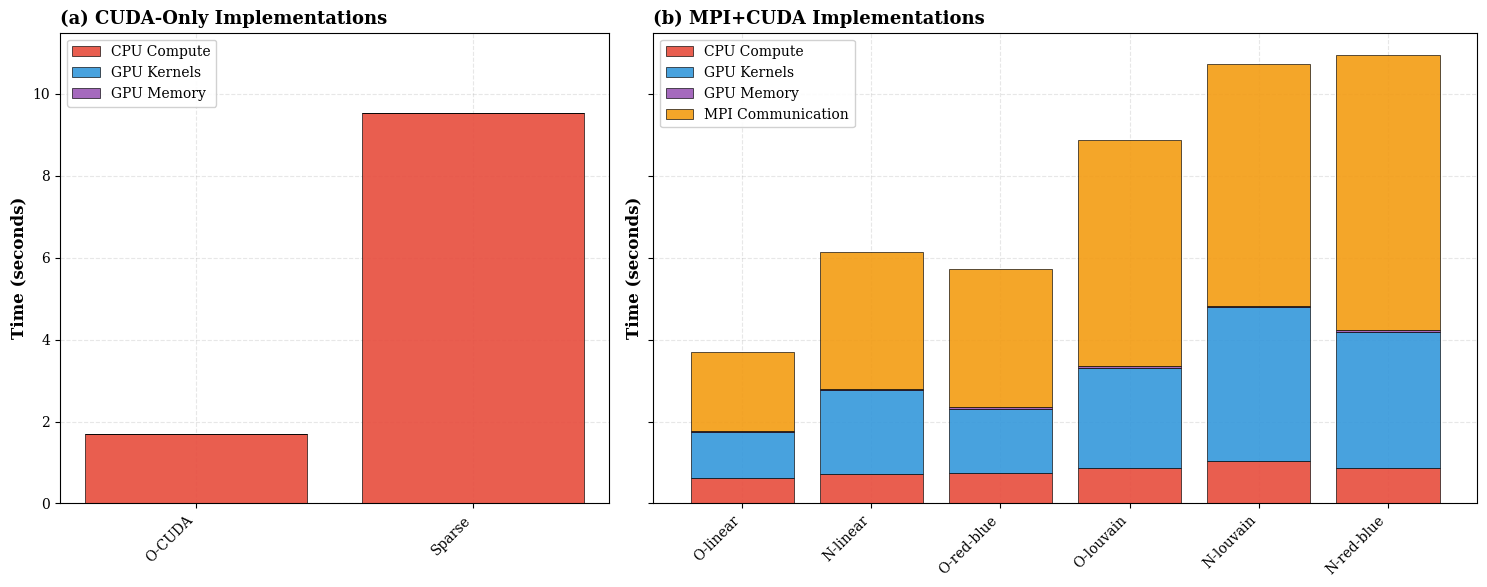

✓ Saved: time_breakdown.pdf/png


In [12]:
# Create stacked bar chart for time breakdown
# Adjust width ratios to reflect number of implementations (2 vs 6)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True, gridspec_kw={'width_ratios': [2, 3]})

# Separate CUDA-only and MPI implementations
cuda_df = perf_df[~perf_df['is_mpi']].sort_values('total_execution_s')
mpi_df = perf_df[perf_df['is_mpi']].sort_values('total_execution_s')

def plot_breakdown(ax, data, title):
    """Helper function to plot time breakdown."""
    if data.empty:
        return
    
    x_pos = np.arange(len(data))
    
    # Create stacked bars
    ax.bar(x_pos, data['cpu_compute_s'], label='CPU Compute', 
           color=COLORS['cpu'], alpha=0.9, edgecolor='black', linewidth=0.5)
    ax.bar(x_pos, data['cuda_kernel_s'], bottom=data['cpu_compute_s'],
           label='GPU Kernels', color=COLORS['gpu_kernel'], alpha=0.9, 
           edgecolor='black', linewidth=0.5)
    ax.bar(x_pos, data['cuda_memory_s'], 
           bottom=data['cpu_compute_s'] + data['cuda_kernel_s'],
           label='GPU Memory', color=COLORS['gpu_memory'], alpha=0.9, 
           edgecolor='black', linewidth=0.5)
    
    if 'mpi_s' in data.columns and data['mpi_s'].sum() > 0:
        ax.bar(x_pos, data['mpi_s'], 
               bottom=data['cpu_compute_s'] + data['cuda_kernel_s'] + data['cuda_memory_s'],
               label='MPI Communication', color=COLORS['mpi'], alpha=0.9, 
               edgecolor='black', linewidth=0.5)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(data['implementation'].apply(
        lambda x: x.replace('naive-cuda-mpi-', 'N-')
                 .replace('optimized-cuda-mpi-', 'O-')
                 .replace('optimized-cuda', 'O-CUDA')
                 .replace('sparse-cuda', 'Sparse')
    ), rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Time (seconds)', fontweight='bold')
    ax.set_title(title, loc='left')
    ax.legend(loc='upper left', framealpha=0.9)
    ax.grid(axis='y', alpha=0.3)

# Plot both panels
plot_breakdown(ax1, cuda_df, '(a) CUDA-Only Implementations')
plot_breakdown(ax2, mpi_df, '(b) MPI+CUDA Implementations')

plt.tight_layout()
plt.show()

print(f"✓ Saved: time_breakdown.pdf/png")

## Visualization 4: Load Balance Analysis for MPI Implementations

Analyze per-rank performance distribution and identify load imbalance.

Analyzing per-rank load balance...


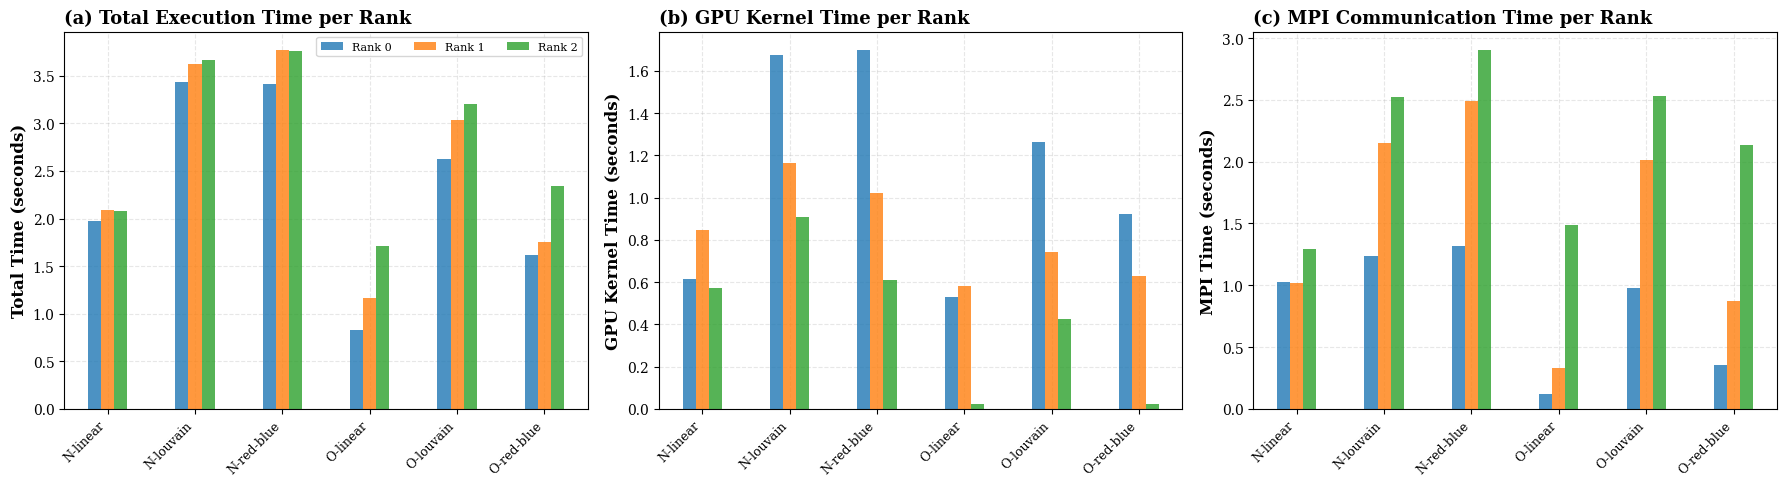

✓ Saved: load_balance_analysis.pdf/png


In [10]:
# Collect per-rank data for MPI implementations
print("Analyzing per-rank load balance...")

rank_data = []
for impl in MPI_IMPLS:
    num_ranks = get_num_ranks(impl)
    if num_ranks <= 1:
        continue
    
    for rank in range(num_ranks):
        breakdown = get_detailed_time_breakdown(impl, rank)
        if breakdown:
            rank_data.append({
                'implementation': impl,
                'rank': rank,
                'total_s': breakdown['total_execution_s'],
                'cuda_kernel_s': breakdown['cuda_kernel_s'],
                'mpi_s': breakdown['mpi_s'],
            })

rank_df = pd.DataFrame(rank_data)

if not rank_df.empty:
    # Create visualization
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # Panel 1: Total execution time per rank
    implementations = rank_df['implementation'].unique()
    max_ranks = rank_df['rank'].max() + 1
    x_pos = np.arange(len(implementations))
    width = 0.15
    
    for rank in range(max_ranks):
        offsets = (rank - max_ranks/2 + 0.5) * width
        times = [rank_df[(rank_df['implementation'] == impl) & 
                        (rank_df['rank'] == rank)]['total_s'].values[0]
                if len(rank_df[(rank_df['implementation'] == impl) & 
                              (rank_df['rank'] == rank)]) > 0 else 0
                for impl in implementations]
        ax1.bar(x_pos + offsets, times, width, label=f'Rank {rank}', alpha=0.8)
    
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([impl.replace('naive-cuda-mpi-', 'N-')
                        .replace('optimized-cuda-mpi-', 'O-')
                        for impl in implementations], rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Total Time (seconds)', fontweight='bold')
    ax1.set_title('(a) Total Execution Time per Rank', loc='left')
    ax1.legend(ncol=3, fontsize=8)
    ax1.grid(axis='y', alpha=0.3)
    
    # Panel 2: GPU kernel time per rank
    for rank in range(max_ranks):
        offsets = (rank - max_ranks/2 + 0.5) * width
        times = [rank_df[(rank_df['implementation'] == impl) & 
                        (rank_df['rank'] == rank)]['cuda_kernel_s'].values[0]
                if len(rank_df[(rank_df['implementation'] == impl) & 
                              (rank_df['rank'] == rank)]) > 0 else 0
                for impl in implementations]
        ax2.bar(x_pos + offsets, times, width, alpha=0.8)
    
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([impl.replace('naive-cuda-mpi-', 'N-')
                        .replace('optimized-cuda-mpi-', 'O-')
                        for impl in implementations], rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('GPU Kernel Time (seconds)', fontweight='bold')
    ax2.set_title('(b) GPU Kernel Time per Rank', loc='left')
    ax2.grid(axis='y', alpha=0.3)
    
    # Panel 3: MPI communication time per rank
    for rank in range(max_ranks):
        offsets = (rank - max_ranks/2 + 0.5) * width
        times = [rank_df[(rank_df['implementation'] == impl) & 
                        (rank_df['rank'] == rank)]['mpi_s'].values[0]
                if len(rank_df[(rank_df['implementation'] == impl) & 
                              (rank_df['rank'] == rank)]) > 0 else 0
                for impl in implementations]
        ax3.bar(x_pos + offsets, times, width, alpha=0.8)
    
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([impl.replace('naive-cuda-mpi-', 'N-')
                        .replace('optimized-cuda-mpi-', 'O-')
                        for impl in implementations], rotation=45, ha='right', fontsize=9)
    ax3.set_ylabel('MPI Time (seconds)', fontweight='bold')
    ax3.set_title('(c) MPI Communication Time per Rank', loc='left')
    ax3.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Saved: load_balance_analysis.pdf/png")
else:
    print("⚠ No multi-rank MPI data available")

## Visualization 6: CUDA Kernel Performance Breakdown

Analyze which CUDA kernels dominate execution time.

Analyzing CUDA kernel breakdown...


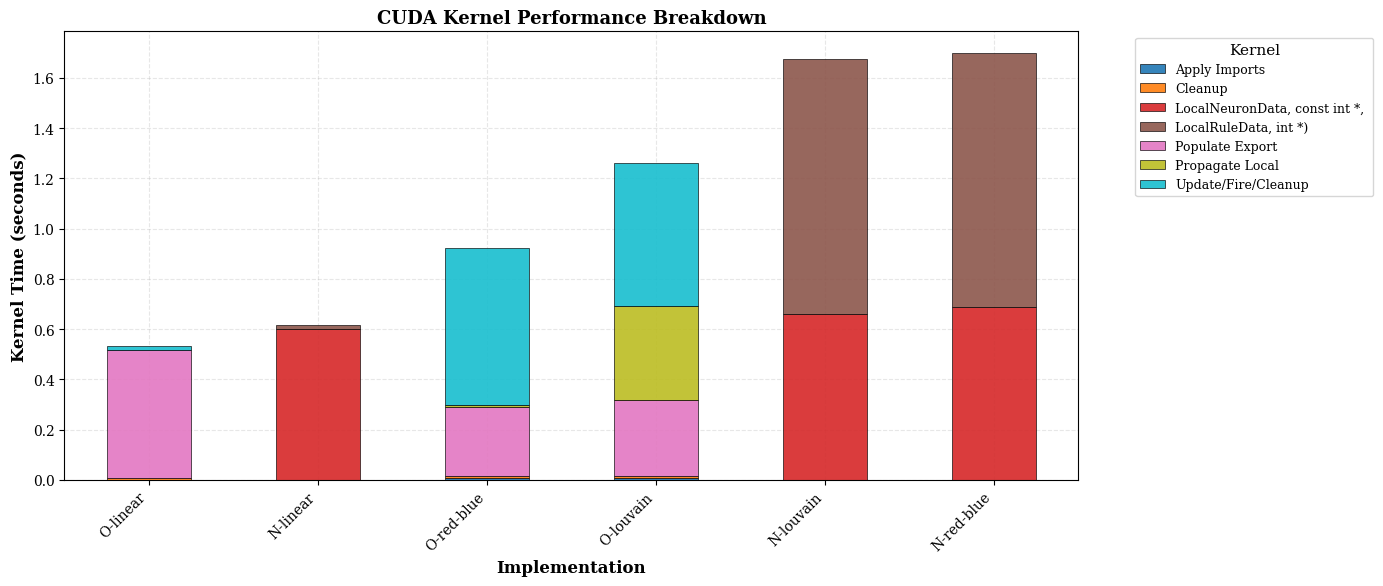

✓ Saved: kernel_breakdown.pdf/png


In [9]:
# Analyze CUDA kernel performance
print("Analyzing CUDA kernel breakdown...")

kernel_data = []
for impl in ALL_IMPLS:
    # Load kernel data (from rank 0 for MPI implementations)
    kernel_df = load_csv_safely(impl, "stats_cuda_gpu_kern_sum.csv", rank=0)
    
    if kernel_df is not None:
        for _, row in kernel_df.iterrows():
            kernel_name = row['Name']
            # Simplify kernel names
            if 'kUpdateSelectFireCleanup' in kernel_name:
                simple_name = 'Update/Fire/Cleanup'
            elif 'kPopulateExport' in kernel_name:
                simple_name = 'Populate Export'
            elif 'kPropagateLocal' in kernel_name:
                simple_name = 'Propagate Local'
            elif 'kApplyImports' in kernel_name:
                simple_name = 'Apply Imports'
            elif 'kCleanupAfterPropagation' in kernel_name:
                simple_name = 'Cleanup'
            else:
                simple_name = kernel_name.split('::')[-1][:30]
            
            kernel_data.append({
                'implementation': impl,
                'kernel': simple_name,
                'time_s': row['Total Time (ns)'] / 1e9,
                'percentage': row['Time (%)'],
            })

kernel_analysis = pd.DataFrame(kernel_data)

if not kernel_analysis.empty:
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Pivot data for stacking
    pivot_data = kernel_analysis.pivot_table(
        index='implementation', 
        columns='kernel', 
        values='time_s', 
        fill_value=0
    )
    
    # Sort implementations
    impl_order = perf_df.sort_values('total_execution_s')['implementation'].tolist()
    pivot_data = pivot_data.reindex([impl for impl in impl_order if impl in pivot_data.index])
    
    # Plot stacked bars
    pivot_data.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', 
                   alpha=0.9, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('Implementation', fontweight='bold')
    ax.set_ylabel('Kernel Time (seconds)', fontweight='bold')
    ax.set_title('CUDA Kernel Performance Breakdown', fontweight='bold')
    ax.set_xticklabels([impl.replace('naive-cuda-mpi-', 'N-')
                       .replace('optimized-cuda-mpi-', 'O-')
                       .replace('optimized-cuda', 'O-CUDA')
                       .replace('sparse-cuda', 'Sparse')
                       for impl in pivot_data.index], 
                      rotation=45, ha='right', fontsize=10)
    ax.legend(title='Kernel', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Saved: kernel_breakdown.pdf/png")
else:
    print("⚠ No kernel data available")